# Day 5 Deep Learning Sprint: Backpropagation — Single Neuron From Scratch

### Project Objective
In this notebook, we will demystify the core engine of deep learning: **Backpropagation**. To build an intuitive and rock-solid foundation, we will build, train, and analyze a single-neuron model from scratch using only Python and NumPy.

No PyTorch, no TensorFlow, no automatic differentiation. Just pure math and code.

## 1. The Computational Graph

Before writing any code, we must visualize how information flows through our single-neuron network. This flow is represented as a **Computational Graph**, where operations are nodes and variables are edges.

Our single neuron processes a single feature input $x$ and passes it through three sequential steps to produce a loss $L$:

$$
x \longrightarrow z = wx + b \longrightarrow a = \sigma(z) \longrightarrow L = \frac{1}{2}(a - y)^2
$$

* **Input ($x$):** The input feature.
* **Linear Combination ($z$):** The weighted input plus bias, $z = wx + b$.
* **Activation ($a$):** The linear output compressed into a probability range $[0, 1]$ via the Sigmoid function: $a = \sigma(z)$.
* **Loss ($L$):** The Mean Squared Error (MSE) style loss measuring how far our prediction $a$ is from the true label $y$.

## 2. Tiny Binary Classification Dataset

Let's define a simple 1D dataset where lower numbers are labeled `0` and higher numbers are labeled `1`.

* Input features: $X = [1, 2, 3, 4, 5, 6]$
* True labels: $y = [0, 0, 0, 1, 1, 1]$

In [11]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
y = np.array([0.0, 0.0, 0.0, 1.0, 1.0, 1.0])

print("Dataset initialized:")
print(f"X: {X}")
print(f"y: {y}")

Dataset initialized:
X: [1. 2. 3. 4. 5. 6.]
y: [0. 0. 0. 1. 1. 1.]


## 3. Explaining and Implementing the Sigmoid Function

The sigmoid function acts as our activation function. It squashes any real-valued number into a range between $0$ and $1$, allowing us to interpret the output as a probability.

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

An extremely elegant property of the sigmoid function is its derivative, which can be expressed entirely in terms of its output:

$$
\frac{d\sigma(z)}{dz} = \sigma(z)(1 - \sigma(z))
$$

In [12]:
def sigmoid(z):
    """
    Computes the sigmoid activation function.
    """
    return 1.0 / (1.0 + np.exp(-z))

test_z = np.array([-5.0, 0.0, 5.0])
print(f"Sigmoid of {test_z} is {sigmoid(test_z)}")

Sigmoid of [-5.  0.  5.] is [0.00669285 0.5        0.99330715]


## 4. Initializing Model Parameters

We must initialize our weights, bias, learning rate, and training epochs. To ensure reproducible results, we will initialize our weight and bias manually or with a fixed seed.

In [13]:
np.random.seed(42)

w = 0.5
b = -0.5

learning_rate = 0.1
epochs = 1000

print(f"Initial weight (w): {w}")
print(f"Initial bias (b): {b}")
print(f"Learning rate: {learning_rate}")

Initial weight (w): 0.5
Initial bias (b): -0.5
Learning rate: 0.1


## 5. Forward Pass and Loss function

During the forward pass, we calculate the predictions for our inputs.

1. Calculate the linear combination:
   $$z_i = w x_i + b$$
2. Compute activation output:
   $$a_i = \sigma(z_i)$$
3. Calculate MSE loss for each example $i$:
   $$L_i = \frac{1}{2}(a_i - y_i)^2$$
4. The average loss over the dataset of size $N$ is:
   $$L_{mean} = \frac{1}{N} \sum_{i=1}^{N} L_i$$

In [14]:
def forward_pass(X, w, b):
    """
    Computes z and a for the entire dataset input X.
    """
    z = w * X + b
    a = sigmoid(z)
    return z, a

def compute_loss(a, y):
    """
    Computes the Mean Squared Error (MSE) style loss.
    """
    return 0.5 * (a - y)**2

## 6. Backpropagation Step-by-Step with Chain Rule

To update our parameters, we need to find how sensitive our loss $L$ is to changes in weight $w$ and bias $b$. In other words, we need to calculate the partial derivatives $\frac{\partial L}{\partial w}$ and $\frac{\partial L}{\partial b}$.

Using the **Chain Rule**, we propagate backward from the output to the input parameters:

### Step 1: Derivative of Loss with respect to Activation ($a$)
$$L = \frac{1}{2}(a - y)^2 \implies \frac{\partial L}{\partial a} = a - y$$

### Step 2: Derivative of Activation ($a$) with respect to Linear Combination ($z$)
$$a = \sigma(z) \implies \frac{\partial a}{\partial z} = a(1 - a)$$

### Step 3: Derivative of Loss with respect to Linear Combination ($z$)
Using the chain rule:
$$\frac{\partial L}{\partial z} = \frac{\partial L}{\partial a} \cdot \frac{\partial a}{\partial z} = (a - y) \cdot a(1 - a)$$

### Step 4: Derivative of Loss with respect to weight ($w$) and bias ($b$)
Since $z = wx + b$:
$$\frac{\partial z}{\partial w} = x \quad \text{and} \quad \frac{\partial z}{\partial b} = 1$$

Therefore, applying the chain rule to the final parameters for a single sample:
$$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial z} \cdot \frac{\partial z}{\partial w} = \frac{\partial L}{\partial z} \cdot x$$
$$\frac{\partial L}{\partial b} = \frac{\partial L}{\partial z} \cdot \frac{\partial z}{\partial b} = \frac{\partial L}{\partial z}$$

To obtain gradients for the whole batch of size $N$, we compute the average gradient:
$$\frac{\partial L_{mean}}{\partial w} = \frac{1}{N} \sum_{i=1}^{N} \frac{\partial L_i}{\partial z} \cdot x_i$$
$$\frac{\partial L_{mean}}{\partial b} = \frac{1}{N} \sum_{i=1}^{N} \frac{\partial L_i}{\partial z}$$

### Parameter Update Rules:
$$w \leftarrow w - \eta \cdot \frac{\partial L_{mean}}{\partial w}$$
$$b \leftarrow b - \eta \cdot \frac{\partial L_{mean}}{\partial b}$$
*(where $\eta$ is the learning rate)*

In [15]:
def backpropagation(X, y, a):
    """
    Computes the gradients using the chain rule.
    """

    dL_da = a - y

    da_dz = a * (1 - a)

    dL_dz = dL_da * da_dz

    dw = np.mean(dL_dz * X)
    db = np.mean(dL_dz)

    return dw, db

## 7. Performing One Gradient-Descent Update

Let's run a single iteration of forward propagation, loss calculation, backpropagation, and parameter updating to see how the values change.

In [16]:

test_w = w
test_b = b

z, a = forward_pass(X, test_w, test_b)
initial_loss = np.mean(compute_loss(a, y))

dw, db = backpropagation(X, y, a)

updated_w = test_w - learning_rate * dw
updated_b = test_b - learning_rate * db

_, new_a = forward_pass(X, updated_w, updated_b)
new_loss = np.mean(compute_loss(new_a, y))

print("=== Before Update ===")
print(f"w: {test_w:.6f}, b: {test_b:.6f}")
print(f"Loss: {initial_loss:.6f}")
print(f"Gradients calculated -> dw: {dw:.6f}, db: {db:.6f}")
print("\n=== After 1 Update Step ===")
print(f"w: {updated_w:.6f}, b: {updated_b:.6f}")
print(f"Loss: {new_loss:.6f}")

=== Before Update ===
w: 0.500000, b: -0.500000
Loss: 0.102095
Gradients calculated -> dw: 0.107575, db: 0.061662

=== After 1 Update Step ===
w: 0.489243, b: -0.506166
Loss: 0.100576


## 8. Training for 1000 Epochs

Now, let's execute the full training loop of 1000 epochs to optimize $w$ and $b$ and verify that the loss steadily decreases.

In [17]:
w = 0.5
b = -0.5

loss_history = []

for epoch in range(epochs):

    z, a = forward_pass(X, w, b)


    loss = np.mean(compute_loss(a, y))
    loss_history.append(loss)


    dw, db = backpropagation(X, y, a)


    w = w - learning_rate * dw
    b = b - learning_rate * db


    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:4d} | Loss: {loss:.6f} | w: {w: .4f} | b: {b: .4f}")

Epoch  100 | Loss: 0.076449 | w:  0.3721 | b: -0.8664
Epoch  200 | Loss: 0.068081 | w:  0.4407 | b: -1.1470
Epoch  300 | Loss: 0.061505 | w:  0.5028 | b: -1.3954
Epoch  400 | Loss: 0.056273 | w:  0.5589 | b: -1.6169
Epoch  500 | Loss: 0.052043 | w:  0.6100 | b: -1.8158
Epoch  600 | Loss: 0.048566 | w:  0.6567 | b: -1.9962
Epoch  700 | Loss: 0.045663 | w:  0.6997 | b: -2.1609
Epoch  800 | Loss: 0.043203 | w:  0.7395 | b: -2.3124
Epoch  900 | Loss: 0.041091 | w:  0.7765 | b: -2.4528
Epoch 1000 | Loss: 0.039256 | w:  0.8112 | b: -2.5837


## 9. Plotting the Loss Curve

Let's visualize the training dynamics using `matplotlib` to ensure smooth convergence.

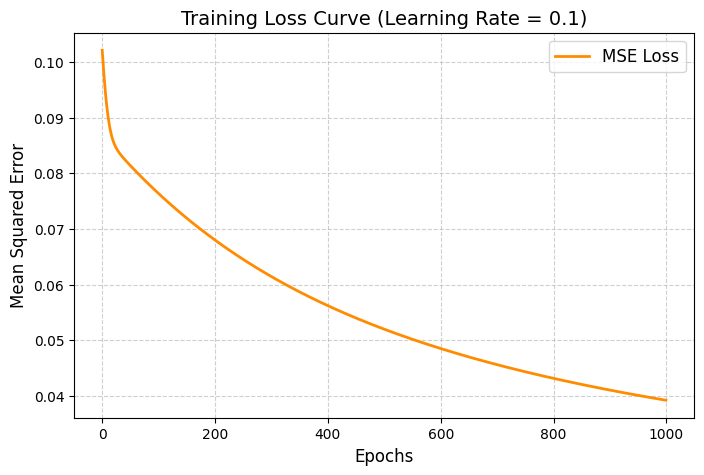

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history, label='MSE Loss', color='darkorange', linewidth=2)
plt.title('Training Loss Curve (Learning Rate = 0.1)', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.show()

## 10. Generating and Evaluating Predictions

Let's calculate final model predictions on our inputs and compare them with the true labels.

In [19]:
_, final_probs = forward_pass(X, w, b)

final_predictions = (final_probs >= 0.5).astype(int)

print("Index | Input X | True y | Pred Prob | Predicted Class")
print("-" * 55)
for i in range(len(X)):
    print(f"{i:5d} | {X[i]:7.1f} | {y[i]:6.0f} | {final_probs[i]:9.4f} | {final_predictions[i]:15d}")

Index | Input X | True y | Pred Prob | Predicted Class
-------------------------------------------------------
    0 |     1.0 |      0 |    0.1452 |               0
    1 |     2.0 |      0 |    0.2766 |               0
    2 |     3.0 |      0 |    0.4626 |               0
    3 |     4.0 |      1 |    0.6595 |               1
    4 |     5.0 |      1 |    0.8134 |               1
    5 |     6.0 |      1 |    0.9075 |               1


## 11. Hyperparameter Experiments: Testing Different Learning Rates

Let's analyze how different learning rates ($\eta = 0.01, 0.1, 1.0$) impact convergence and the ultimate loss values.

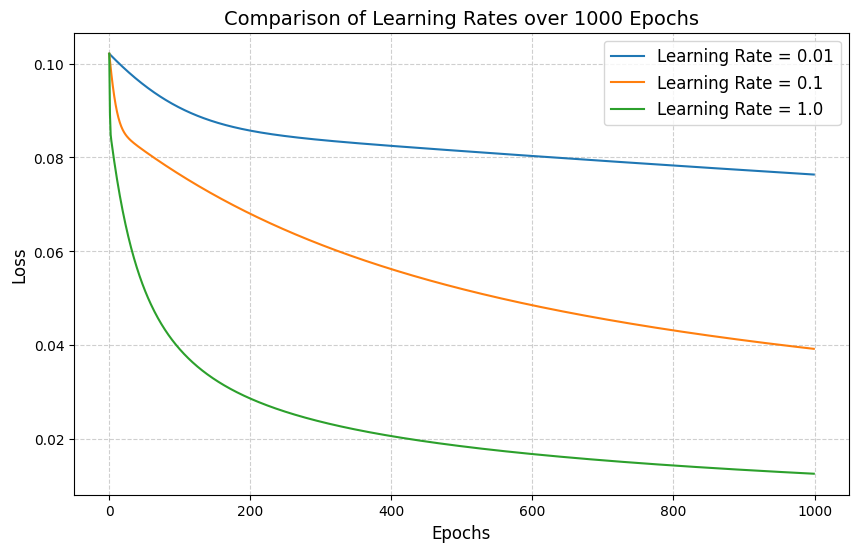

In [20]:
learning_rates = [0.01, 0.1, 1.0]
results = {}

for lr in learning_rates:

    w_exp = 0.5
    b_exp = -0.5
    exp_loss_history = []

    for epoch in range(1000):
        z_exp, a_exp = forward_pass(X, w_exp, b_exp)
        loss_exp = np.mean(compute_loss(a_exp, y))
        exp_loss_history.append(loss_exp)

        dw_exp, db_exp = backpropagation(X, y, a_exp)

        w_exp = w_exp - lr * dw_exp
        b_exp = b_exp - lr * db_exp

    results[lr] = exp_loss_history

plt.figure(figsize=(10, 6))
for lr, hist in results.items():
    plt.plot(hist, label=f"Learning Rate = {lr}")

plt.title("Comparison of Learning Rates over 1000 Epochs", fontsize=14)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.show()

## 12. What I Learned

In this project, we built a single neuron from scratch. Here is a summary of the foundational deep learning concepts we mastered:

1. **Computational Graphs**: Expressing functions as graphical flows helps track dependencies and maps how inputs $x$ and parameters $w, b$ transform sequentially to calculate predictions $a$ and errors $L$.
2. **Forward Propagation**: The process of passing inputs through network layers (linear equations and non-linear activations like Sigmoid) to generate prediction values.
3. **Chain Rule**: The fundamental rule of calculus that enables us to calculate the derivative of a composite function. By calculating sequential gradients from the outer layers to inner parameters, we can link $\frac{\partial L}{\partial a}$, $\frac{\partial a}{\partial z}$, and $\frac{\partial z}{\partial w}$ to obtain $\frac{\partial L}{\partial w}$.
4. **Gradients**: Multivariable derivatives pointing in the direction of steepest ascent. By computing negative gradients, we determine how to update parameters to reduce the output error.
5. **Backpropagation**: The systematic application of the Chain Rule across computational graphs to calculate parameter gradients efficiently.
6. **Gradient Descent**: An optimization algorithm that iteratively adjusts weights and biases ($w \leftarrow w - \eta \cdot dw$) to locate the global/local minimum of the loss surface. The learning rate $\eta$ plays a vital role in determining convergence speed and stability.